In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import anndata
core = 5
adata_path = f"/home/longinus723/home/Cell_Annotation/0050585/combined_cluster_core_{core}.h5ad"

adata = anndata.read_h5ad(adata_path)

print(adata)

AnnData object with n_obs × n_vars = 4752 × 1000
    obs: 'cell_id', 'expression_louvain_label', 'leiden', 'cell_type'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Spatial_Net', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'louvain', 'neighbors', 'pca', 'umap'
    obsm: 'STAGATE', 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


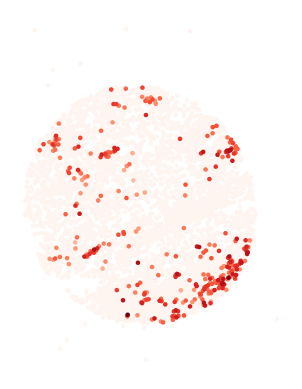

In [26]:
import scanpy as sc
import matplotlib.pyplot as plt

gene_name = "MMP9"

# Figure 객체 반환
fig = sc.pl.spatial(
    adata,
    color=gene_name,
    cmap="Reds",
    title="",
    spot_size=20,
    frameon=False,
    show=False,
    return_fig=True  # Figure 객체 반환
)

# 컬러바를 포함하는 Axes 찾기
for ax in fig.axes:
    if ax.get_position().x1 > 0.85:  # 컬러바 위치 (오른쪽에 존재)
        fig.delaxes(ax)  # 컬러바 제거

# 컬러바 제거된 그림 출력
plt.show()


In [ ]:
# 'cell_type' 값 변경
adata.obs['cell_type'] = adata.obs['cell_type'].replace({'Cancer-associated fibroblasts (CAFs)': 'Cancer-associated fibroblast'})

# 변경된 내용 확인
print(adata.obs['cell_type'].unique().tolist())






In [ ]:
import os
adata_path = "/home/longinus723/home/Cell_Annotation/0050585/"
save_h5ad_path = os.path.join(adata_path, f"updated_clusterlabel_core_{core}.h5ad")
print(core)
adata.write(save_h5ad_path)
print(f"수정된 anndata 파일 저장 완료: {save_h5ad_path}")

In [ ]:
import scanpy as sc
import anndata



corelist = [1,3,5]
for core in corelist:
    path = f"/home/longinus723/home/Cell_Annotation/0050585/updated_clusterlabel_core_{core}.h5ad"
    ann_data = anndata.read_h5ad(path)




    sc.pl.umap(ann_data, color='cell_type', title=f"Core {core} (Cell Type Annotation)")

    # Spatial 플롯 그리기 (spatial 좌표가 adata.obsm['spatial']에 저장되어 있어야 함)
    sc.pl.spatial(ann_data, color='cell_type', spot_size=15, title=f"Core {core} Spatial (Cell Type Annotation)")

In [5]:
import warnings
warnings.filterwarnings("ignore")
import anndata
import scanpy as sc
slide = "0050585"


#0050585
NL = [1, 3, 5]




for core in NL:
    file_path = f"/home/longinus723/home/Cell_Annotation/{slide}/updated_clusterlabel_core_{core}.h5ad"
    print("=========================================")
    print(f"core {core} Gene 추출 시작")
    adata = anndata.read_h5ad(file_path)

    sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
    ranked_genes = adata.uns["rank_genes_groups"]
    clusters = ranked_genes["names"].dtype.names  # 클러스터 이름 목록
    for cluster in clusters:
        top_genes = ranked_genes["names"][cluster][:15]
        print(f" {cluster}: {top_genes}")


        

core 1 Gene 추출 시작
 Colon epithelial cells: ['SLC26A2' 'EPCAM' 'MALL' 'KRT20' 'ATP1A1' 'SLC26A3' 'FCGBP' 'CDKN1A'
 'ATP5F1A' 'CEACAM1' 'SLC9A3' 'AQP8' 'CD177' 'EMP1' 'TCIM']
 Endothelial cells: ['EPAS1' 'PECAM1' 'JAM2' 'CLDN5' 'TGFBR2' 'SHANK3' 'SOCS3' 'CCL14' 'LIFR'
 'CAVIN2' 'CLEC14A' 'FAM107A' 'SULF1' 'TEK' 'S1PR1']
 Epithelial cell: ['EPCAM' 'ATP1A1' 'FCGBP' 'ATP5F1A' 'SLC26A2' 'TUBB' 'XBP1' 'SMOC2'
 'TRPA1' 'FMOD' 'KRT20' 'DeprecatedCodeword_17303' 'TENT5C' 'PSIP1' 'SCG5']
 Fibroblast: ['ADAMTS1' 'TIMP2' 'CCN1' 'CCN2' 'GREM2' 'GREM1' 'CXCL12' 'NR4A1' 'CCDC80'
 'AOC3' 'COL4A2' 'SDC2' 'COL5A1' 'LAMC1' 'PDE5A']
 Macrophage: ['ADAMDEC1' 'SLC40A1' 'CTSC' 'CCL8' 'CD4' 'CXCR4' 'MAF' 'SLCO2B1' 'STAB1'
 'ITGB2' 'COL5A1' 'SNAI2' 'MRC1' 'CD3E' 'LGMN']
 Mast cell: ['KIT' 'CTSG' 'MS4A2' 'CMA1' 'SLC18A2' 'GATA2' 'SIGLEC6' 'CD44' 'IKZF1'
 'IL1RL1' 'MAOB' 'HDC' 'HPGDS' 'CNRIP1' 'ADRB2']
 Pericytes: ['PLN' 'MCAM' 'LBH' 'MYLK' 'DeprecatedCodeword_1307' 'DPT' 'RCAN2' 'AOC3'
 'BCAM' 'NOTCH3' 'FRZB' 'C

core 2 Gene 추출 및 dotplot 생성
 - Colon epithelial cells: ['SLC26A2', 'EPCAM', 'SELENBP1', 'HSD11B2', 'CA12', 'ATP1A1', 'TSPAN8', 'ATP5F1A', 'ST14', 'PDXDC1', 'FCGBP', 'KRT20', 'MALL', 'CDKN1A', 'SLC26A3']
 - Endothelial cells: ['PLVAP', 'TGFBR2', 'EPAS1', 'CLDN5', 'JAM2', 'PECAM1', 'SHANK3', 'LIFR', 'CD34', 'ENPP2', 'ENG', 'S1PR1', 'EGFL7', 'CAVIN2', 'TIE1']
 - Epithelial cells: ['EPCAM', 'TSPAN8', 'SLC12A2', 'ST14', 'ATP1A1', 'PDXDC1', 'FCGBP', 'CA12', 'ATP5F1A', 'APP', 'ALDH1B1', 'TUBB', 'NBL1', 'SELENBP1', 'HSD11B2']
 - Fibroblast: ['ADAMTS1', 'GREM2', 'TIMP2', 'GREM1', 'PDE5A', 'MYLK', 'COL4A1', 'SYNPO2', 'MXRA7', 'AOC3', 'COL4A2', 'CCN2', 'CSRP1', 'FSTL1', 'CCN1']
 - Macrophage: ['MRC1', 'STAB1', 'SLC40A1', 'FCGR2A', 'SLCO2B1', 'CD4', 'LGMN', 'CTSC', 'CD163', 'ITGB2', 'CD14', 'F13A1', 'CSF1R', 'CD68', 'SIGLEC1']
 - Mast cell: ['KIT', 'CMA1', 'CTSG', 'MS4A2', 'SIGLEC6', 'SLC18A2', 'CD44', 'GATA2', 'HDC', 'IL1RL1', 'HPGDS', 'BTK', 'IKZF1', 'ALOX5', 'MAOB']
 - Pericyte: ['EPAS1', 'LBH'

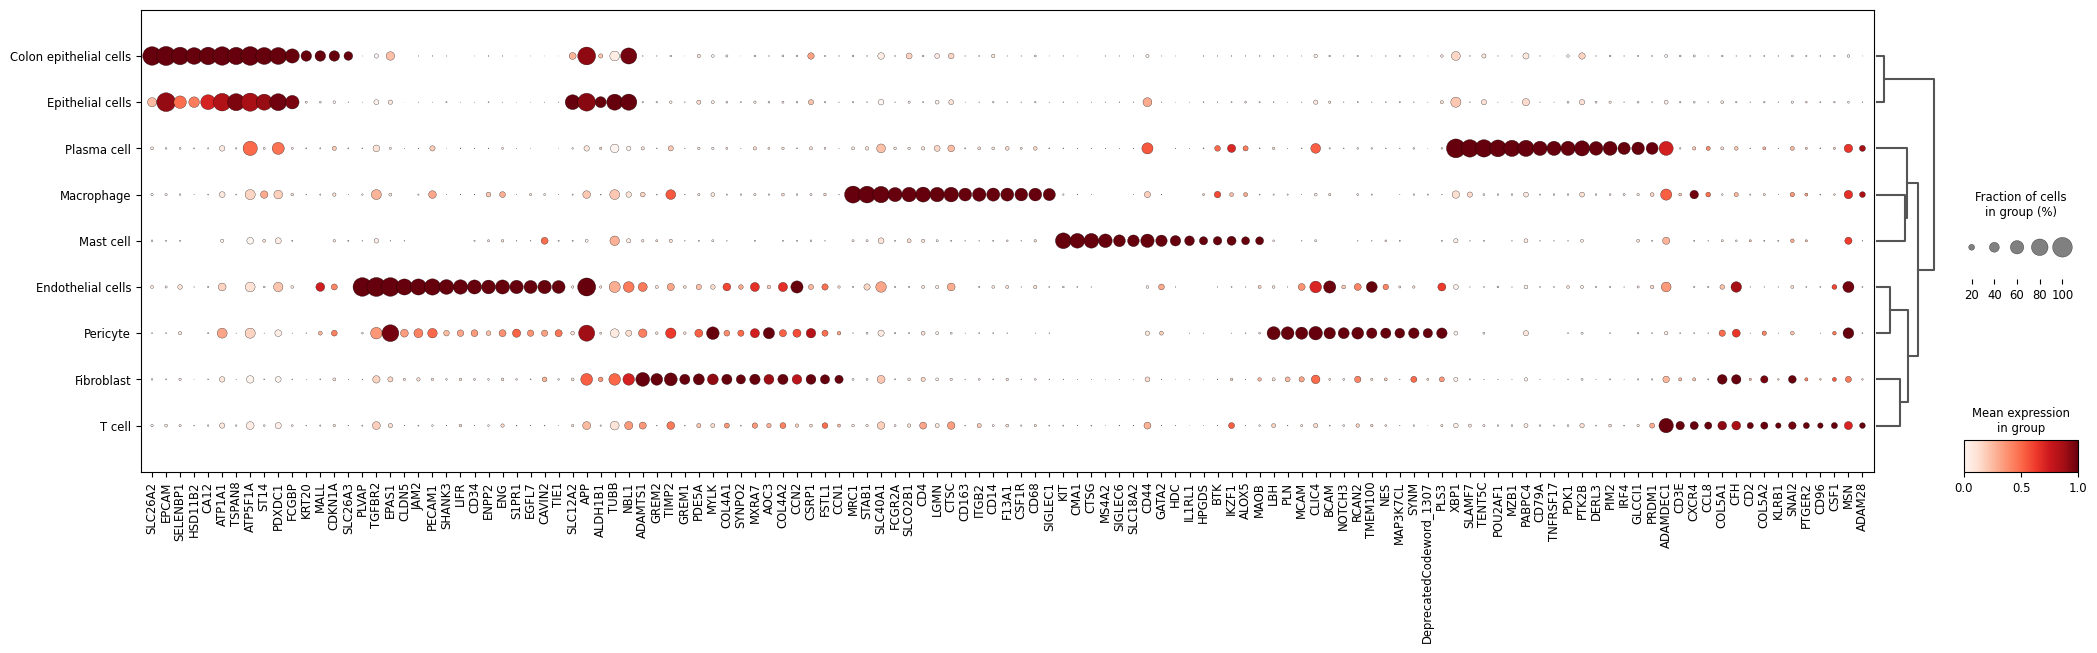

core 4 Gene 추출 및 dotplot 생성
 - Epithelial cells: ['EPCAM', 'ANPEP', 'DSG2', 'CA9', 'APOL1', 'TMEM45B', 'CDH1', 'MUC1', 'ERBB3', 'NDRG1', 'IFITM1', 'SLC12A2', 'MUC5B', 'TSPAN8', 'ALDOA']
 - Fibroblast: ['POSTN', 'MMP14', 'COL5A1', 'TIMP2', 'CXCR4', 'GNAI2', 'ITGB2', 'SLAMF7', 'SULF1', 'MAN2B1', 'THY1', 'MSN', 'COL5A2', 'MAFB', 'CD4']
 - Macrophage: ['MMP12', 'CTSL', 'CD68', 'SLC2A3', 'FCGR2A', 'CXCR4', 'ITGB2', 'PLAUR', 'SNX10', 'CD300A', 'MMP9', 'ADAMDEC1', 'ADM', 'ADAM8', 'ABCA1']
 - Neutrophil: ['CXCR4', 'SLC2A3', 'FCGR3B', 'HCAR3', 'BCL2A1', 'CLEC4A', 'CCRL2', 'HCAR2', 'CSF3R', 'KCNJ15', 'NCF1', 'AQP9', 'TEK', 'CYBB', 'PLAU']
 - Proliferating T cells: ['NR4A1', 'CCND2', 'C1QBP', 'LIF', 'HSPA9', 'NME1', 'CYCS', 'SPTBN1', 'FBL', 'MCM7', 'MCM4', 'CCT7', 'AHCY', 'MCM3', 'CCT2']
 - Proliferating Tumor Cells: ['UBD', 'MCM4', 'MCM7', 'PRKDC', 'MCM3', 'FBL', 'IGFBP2', 'C1QBP', 'TYMS', 'AHCY', 'CXCL10', 'BIRC5', 'NME1', 'PCNA', 'TUBB']
 - Proliferating cancer cells: ['AHCY', 'PRKDC', 'MCM4',

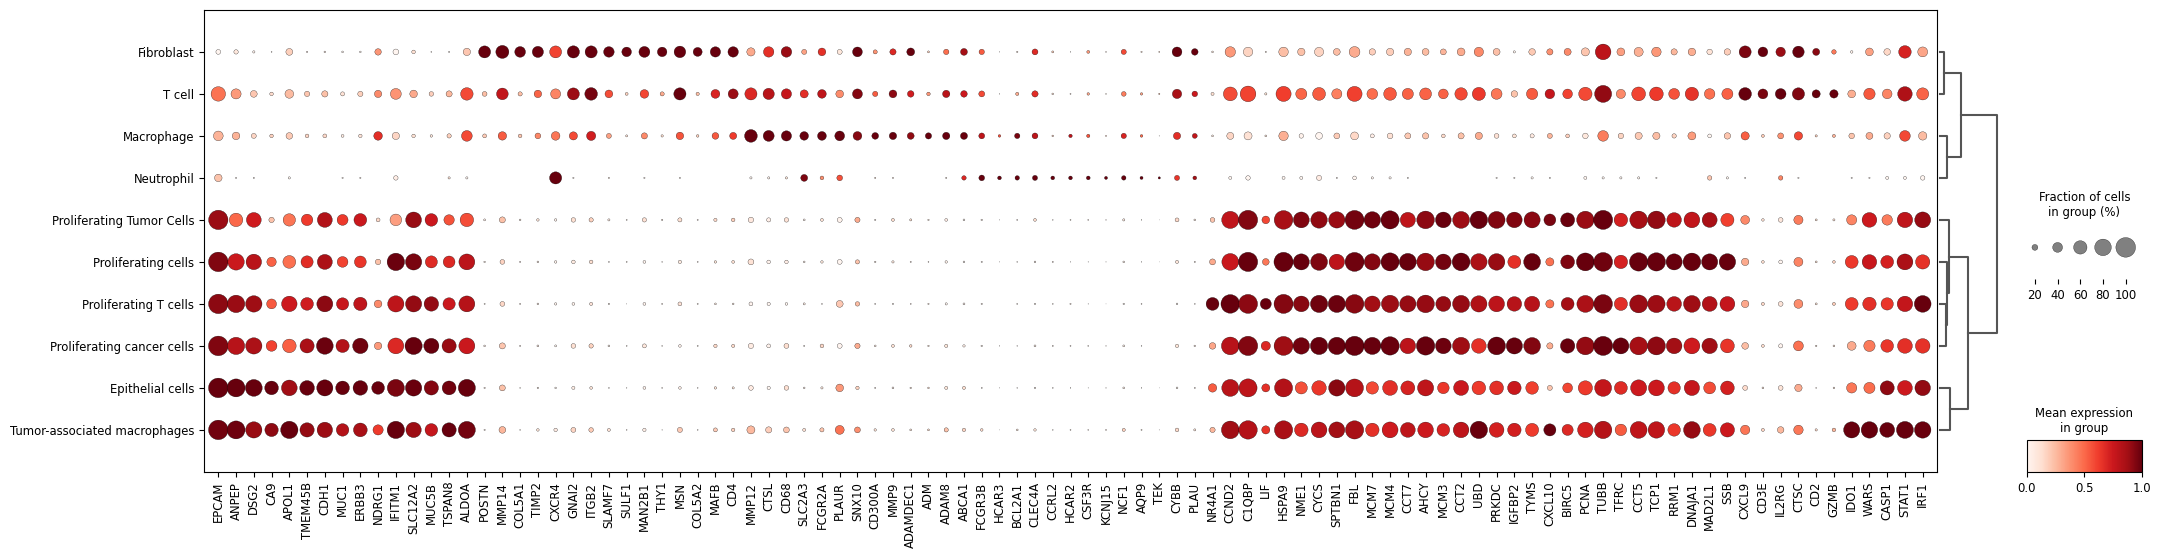

core 6 Gene 추출 및 dotplot 생성
 - Cancer-associated fibroblasts (CAFs): ['POSTN', 'COL5A1', 'SULF1', 'CTHRC1', 'COL5A2', 'MMP14', 'SFRP4', 'THY1', 'TIMP2', 'THBS1', 'THBS2', 'SERPINH1', 'COL11A1', 'AEBP1', 'CCDC80']
 - Endothelial cells: ['COL4A1', 'COL4A2', 'HSPG2', 'EPAS1', 'PECAM1', 'COL18A1', 'PLVAP', 'MCAM', 'SERPINH1', 'ADAMTS1', 'CD93', 'ENG', 'KDR', 'TIE1', 'THY1']
 - Epithelial cells: ['EPCAM', 'HSPD1', 'SNHG15', 'SOD1', 'HSPA9', 'C1QBP', 'APOL1', 'UBD', 'IRF1', 'CXCL2', 'LIF', 'SOST', 'SOX2-OT', 'DUX4', 'C4A']
 - Macrophage: ['CXCL9', 'ITGB2', 'CD4', 'MSN', 'CD68', 'MMP12', 'TUBB', 'CYBB', 'CTSC', 'IL2RG', 'SNX10', 'CTSL', 'RAP1A', 'CD3E', 'MAFB']
 - Natural Killer (NK) cells: ['GRM3', 'CALCR', 'KCNE1', 'CORT', 'CAVIN2', 'KLRC2', 'RNF112', 'PDGFD', 'KLRD1', 'BCL2A1', 'CD14', 'GPR174', 'IKZF2', 'TBXAS1', 'NFATC2']
 - Plasma cell: ['XBP1', 'CXCR4', 'PIM2', 'MZB1', 'POU2AF1', 'FCGR2A', 'TENT5C', 'SLAMF7', 'ERN1', 'SOX2-OT', 'MAFB', 'DERL3', 'PECAM1', 'MIAT', 'PRDM1']
 - T cell: ['C

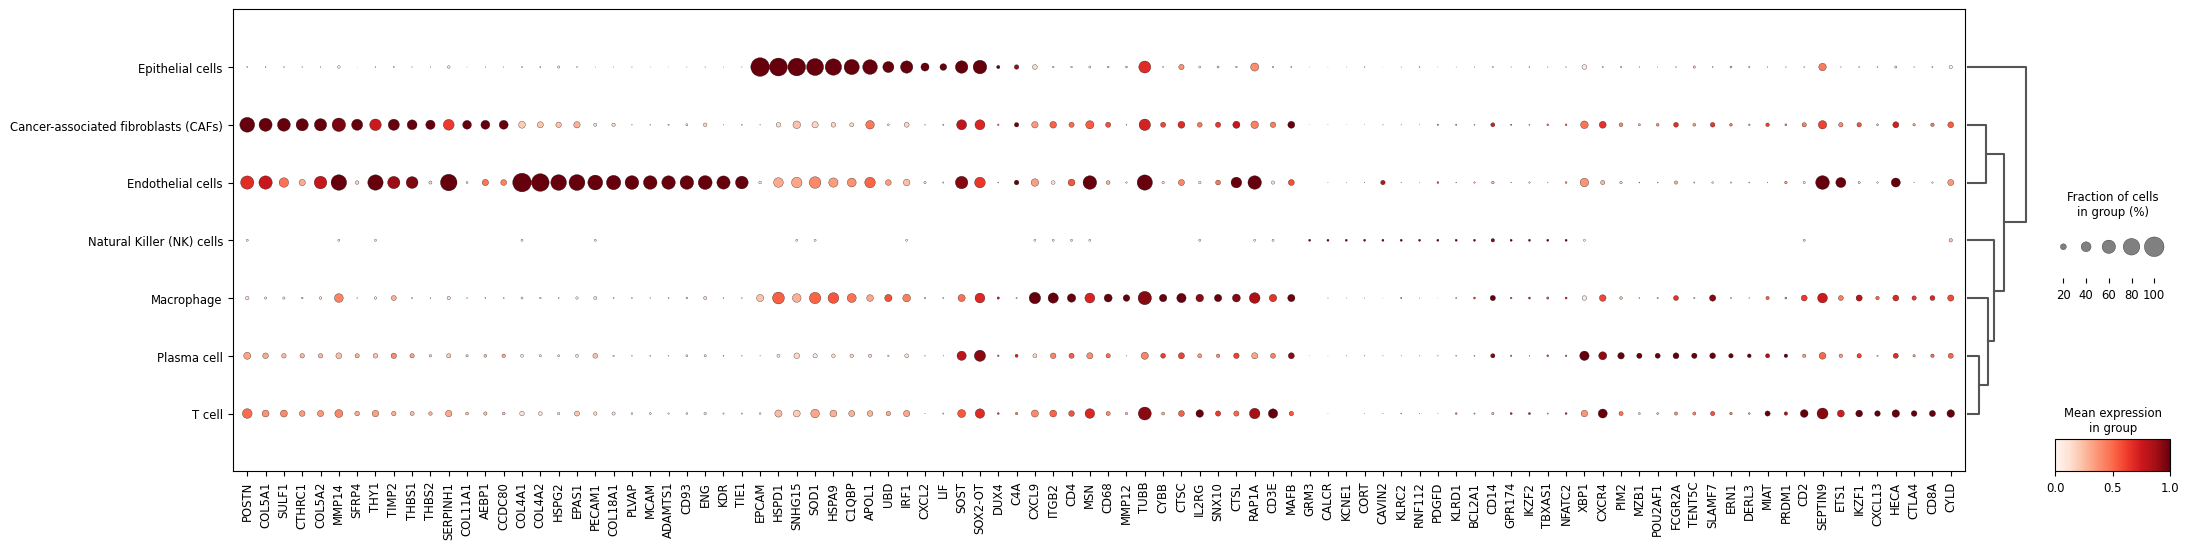

In [10]:
import warnings
warnings.filterwarnings("ignore")
import anndata
import scanpy as sc

slide = "0050585"
NL = [1, 3, 5]
wtf= [2,4,6]

for core in wtf:
    file_path = f"/home/longinus723/home/Cell_Annotation/{slide}/combined_cluster_core_{core}.h5ad"
    print("=========================================")
    print(f"core {core} Gene 추출 및 dotplot 생성")

    adata = anndata.read_h5ad(file_path)

    # (1) Wilcoxon rank genes 수행
    sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")

    # (2) rank_genes_groups 결과에서 각 cell_type(클러스터)별 상위 15개 유전자 수집
    ranked_genes = adata.uns["rank_genes_groups"]
    clusters = ranked_genes["names"].dtype.names  # 클러스터(셀 타입) 이름 목록

    top_n = 15
    all_top_genes = []
    for cluster in clusters:
        top_genes = ranked_genes["names"][cluster][:top_n].tolist()
        all_top_genes.extend(top_genes)
        print(f" - {cluster}: {top_genes}")

    # (3) 중복 제거(같은 유전자가 여러 클러스터에서 상위로 나올 수 있으므로)
    # 순서 유지를 위해 dict.fromkeys() 사용
    all_top_genes = list(dict.fromkeys(all_top_genes))
    print("all_top_genes:", all_top_genes)

    # (4) dotplot 생성
    sc.pl.dotplot(
        adata,
        var_names=all_top_genes,     # 시각화할 유전자 목록
        groupby="cell_type",         # cell_type별로 발현 확인
        standard_scale="var",        # 각 유전자(가로축)별로 발현량을 표준화
        dendrogram=True,             # 세로축(클러스터) 유사도에 따른 덴드로그램
        figsize=(25, 6),
        show=True                    # 주피터 노트북 상에서 즉시 보여줌
    )


In [1]:
s1 = "Hello"
s2 = "World"

# (1) 두 문자열을 연결하여 "HelloWorld" 만들기
result1 = s1 + s2
print("(1)", result1)

# (2) s1을 3번 반복하여 출력하기
result2 = s1 * 3
print("(2)", result2)

# (3) s2의 길이 출력하기
result3 = len(s2)
print("(3)", result3)

# (4) "Hello, World!" 형태로 출력하기 (콤마 포함)
result4 = f"{s1}, {s2}!"
print("(4)", result4)


(1) HelloWorld
(2) HelloHelloHello
(3) 5
(4) Hello, World!


In [3]:
y = 4.2e-2 

In [4]:
print(y)

0.042


In [7]:
f"{y:.4f}"

'0.0420'

In [ ]:
pie = 3.141592


3.3333333333333335
<class 'float'>
3
<class 'int'>


In [16]:
x = float(input())


"""반올림은 5를 기준으로 넘으면 올림, 넘지 않으면 내리기 때문에 
소수 셋째자리에 5를 더해주고 100을 곱한 후
이후에 int로 변환해 소수점을 버리고 다시 100으로 나누어 소수점 둘째자리까지 출력한다."""

result = int((x + 0.005) * 100) / 100

# 예시
# x가 2.336이라 가정
# x + 0.005 = 2.341
# 2.341 * 100 = 234.1
# int(234.1) = 234
# 234 / 100 = 2.34


print(result)


1.11


In [ ]:
#주석(프로그램 실행에는 영향이 없음)